# Central Bessel Lobe Analysis — aug5 dataset (what the Sr atoms actually see)

Same analysis as `axicon3_central_bessel_lobe_2026_07_30.ipynb`, on the 2026-08-05 scans in the new
L$_{12}$=175 mm / L$_{23}$=415 mm geometry (frames now uint8, 1 cm slice pitch). Snapshot through
20-07-52 (scanning was still in progress at 20:12); the caches are incremental — rerun the list +
thumbnail cells to pull in later runs. y = 73–79 cm unscanned.

rate_c_per_us = peak pixel rate for a given frame, calculated from max_counts / exposure_us
ratio_to_slice_best = the rate_c_per_us quantity for frame divided by the highest (best) rate_c_per_us for the entire y slice. i.e. ratio_to_slice_best = 1.0 means frame contains max_counts pixel(s)

| run | placement | anchor y (mm) | slices | beam y (cm) |
|---|---|---|---|---|
| 18-02-56 | aug5_axicon3_005 | 600 | 13 | 60–72 |
| 18-40-54 | aug5_axicon3_006 | 700 | 1 | 70 — saturated, excluded |
| 18-46-51 | aug5_axicon3_006 | 600 | 13 | 60–72 |
| 19-02-13 | aug5_axicon3_007 | 800 | 12 | 80–91 |
| 19-22-29 | aug5_axicon3_008 | 900 | 13 | 90–102 |
| 19-38-21 | aug5_axicon3_010 | 1000 | 13 | 100–112 |
| 19-45-36 | aug5_axicon3_010 | 1100 | 7 | 110–116 |
| 19-52-30 | aug5_axicon3_010 | 1160 | 7 | 116–122 |
| 20-00-16 | aug5_axicon3_011 | 1200 | 1 | 120 — exposure railed at 500 ms (beam absent), excluded |
| 20-07-52 | aug5_axicon3_011 | 1200 | 13 | 120–132 |

In [ ]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent

RUNS = [" data/auto_scan-2026-08-05_22-45-32",
]
RUN_DIRS = {r: REPO / "profiler/data" / r for r in RUNS}

PX_UM = 3.45                       # native camera pixel (µm)
FRAME_SHAPE = (1536, 2048)         # raw frame (rows, cols)
D_IN_MM = 9.30                     # 1/e² input diameter after telescope (recorded GaussianBeamWaist_mm = 4.65)
ALPHA3_DEG = 0.5
THETA3_MRAD = 4.00                 # deflection after axicon 3

# Every figure is also written out as images/<notebook filename>/<description>.png.
OPTIC_TITLE = ("axicon1,2 alpha = 5.0deg, axicon3 alpha = 0.5deg, "
               "L$_{12}$ separation = 175.0mm, L$_{23}$ separation = 415.0mm")

NOTEBOOK_STEM = "axicon3_central_bessel_lobe_2026_08_05"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

In [45]:
# --- core-frame list: raw frames containing the central Bessel lobe ----------
# Selection (manifest-only, no image files opened):
#   1. every aug5 auto_scan run dir with a frames.jsonl — including the
#      saturated 18-40-54 and the beam-absent 20-00-16, marked excluded_run=True
#   2. keep ScanKind == "AutoBeamStack", drop '-dark' relabeled proof frames;
#      a truncated trailing line (run still writing) is skipped with a warning
#   3. per slice, per-frame peak rate = Max / Exposure_us; a frame contains
#      the core if its rate >= CORE_RATIO_MIN x the slice's best rate.
#      Halo-only frames sit below ~0.2 of the slice best; every overlapping
#      raster cell that shares the core reads ~the slice maximum, so the
#      ratio distribution is strongly bimodal and 0.5 splits it cleanly
#   4. saturated frames are KEPT and flagged n_sat_px > 0 (core present,
#      clipped) — filter on that column for photometric work
#   5. writes reductions/ax3_core_frames_2026_08_05.csv (one row per core
#      frame, sorted by beam y; ratio column included so the cut can be
#      re-drawn)
import csv

CORE_RATIO_MIN = 0.5
EXCLUDED = {"auto_scan-2026-08-05_18-40-54",   # single y70 frame, saturated
            "auto_scan-2026-08-05_18-46-51",
            "auto_scan-2026-08-05_19-02-13"
            }   # exposure railed at 500 ms
                                               # (beam absent) — y120 re-scanned
                                               # minutes later by 20-07-52

core_rows = []
scan_dirs = sorted(d for d in (REPO / "profiler/data").glob("auto_scan-2026-08-05_*")
                   if (d / "frames.jsonl").exists() if "MISALIGNED" not in d.name and "ERROR" not in d.name)
for run_dir in scan_dirs:
    slices = {}
    for ln, line in enumerate(open(run_dir / "frames.jsonl"), start=1):
        if not line.strip():
            continue
        try:
            rec = json.loads(line)
        except json.JSONDecodeError as e:
            print(f"WARNING {run_dir.name} frames.jsonl:{ln} unparseable "
                  f"({e}) — skipped (run still writing?)")
            continue
        ex = rec.get("Extra", {})
        if ex.get("ScanKind") != "AutoBeamStack":
            continue
        if Path(rec["Path"]).stem.endswith("-dark"):
            continue
        slices.setdefault(ex["Subfolder"], []).append(rec)
    for sub, recs in sorted(slices.items()):
        best = max(r["Max"] / r["Extra"]["Exposure_us"] for r in recs)
        for r in recs:
            rate = r["Max"] / r["Extra"]["Exposure_us"]
            if rate < CORE_RATIO_MIN * best:
                continue
            core_rows.append(dict(
                beam_y_cm=r["Extra"]["BeamY_mm"] / 10.0,
                run=run_dir.name, slice=sub, frame=Path(r["Path"]).name,
                gantry_x_mm=r["GantryPosition_mm"]["x_mm"],
                gantry_z_mm=r["GantryPosition_mm"]["z_mm"],
                max_counts=r["Max"],
                exposure_us=round(r["Extra"]["Exposure_us"], 1),
                rate_c_per_us=round(rate, 4),
                ratio_to_slice_best=round(rate / best, 3),
                n_sat_px=r.get("SaturatedPixelCount", 0),
                excluded_run=run_dir.name in EXCLUDED))
core_rows.sort(key=lambda r: (r["beam_y_cm"], r["run"], r["frame"]))
CORE_CSV = Path("reductions/ax3_core_frames_2026_08_05.csv")
with open(CORE_CSV, "w", newline="") as fh:
    wcsv = csv.DictWriter(fh, fieldnames=list(core_rows[0].keys()))
    wcsv.writeheader()
    wcsv.writerows(core_rows)
n_main = sum(not r["excluded_run"] for r in core_rows)
n_sat = sum(r["n_sat_px"] > 0 for r in core_rows)
print(f"{len(core_rows)} core frames -> {CORE_CSV} "
      f"({n_main} from analysis runs, {len(core_rows) - n_main} from excluded "
      f"runs, {n_sat} saturated)")
for run_dir in scan_dirs:
    n = sum(1 for r in core_rows if r["run"] == run_dir.name)
    print(f"  {run_dir.name}: {n}")

44 core frames -> reductions/ax3_core_frames_2026_08_05.csv (44 from analysis runs, 0 from excluded runs, 2 saturated)
  auto_scan-2026-08-05_21-53-51: 44


In [46]:
# --- core-frame thumbnails, cached (incremental) -----------------------------
# Preprocessing (input list: reductions/ax3_core_frames_2026_08_05.csv):
#   1. keep analysis-run rows only (excluded_run == False) with no saturated
#      pixels (n_sat_px == 0)
#   2. load each raw frame, crop +-144 native px (+-497 um) about its peak
#      pixel (the core); regions off the sensor stay NaN
#   3. 2x2 mean-pool -> 144x144 thumbnails at 6.9 um/px, raw counts
#   4. the cache is INCREMENTAL: (run, frame) rows missing from the npz are
#      reduced from raw and appended, so re-running the list cell + this one
#      picks up scans from later in the evening — delete the npz to force a
#      full rebuild from raw frames
import csv

THUMB_CACHE = Path("reductions/ax3_core_thumbs_2026_08_05.npz")
HALF_PX, POOL = 144, 2

rows = [r for r in csv.DictReader(open(CORE_CSV))
        if r["excluded_run"] == "False" and int(r["n_sat_px"]) == 0]
if THUMB_CACHE.exists():
    _d = np.load(THUMB_CACHE, allow_pickle=True)
    core_thumbs, ct_ys = _d["thumbs"].astype(np.float32), _d["ys_cm"]
    ct_runs, ct_frames = _d["runs"], _d["frames"]
    print(f"loaded cached core thumbnails {core_thumbs.shape}")
else:
    core_thumbs = np.zeros((0, 2 * HALF_PX // POOL, 2 * HALF_PX // POOL),
                           np.float32)
    ct_ys = np.zeros(0)
    ct_runs = ct_frames = np.zeros(0, dtype="U8")

have = set(zip(ct_runs.tolist(), ct_frames.tolist()))
todo = [r for r in rows if (r["run"], r["frame"]) not in have]
if todo:
    thumbs, ys_l, runs_l, frames_l = [], [], [], []
    for r in todo:
        p = REPO / "profiler/data" / r["run"] / r["slice"] / r["frame"]
        if not p.exists():
            print(f"MISSING raw frame {p} — left out of the gallery")
            continue
        a = np.load(p).astype(np.float32)
        iy, ix = np.unravel_index(np.argmax(a), a.shape)
        crop = np.full((2 * HALF_PX, 2 * HALF_PX), np.nan, np.float32)
        y0, y1 = max(iy - HALF_PX, 0), min(iy + HALF_PX, a.shape[0])
        x0, x1 = max(ix - HALF_PX, 0), min(ix + HALF_PX, a.shape[1])
        crop[y0 - (iy - HALF_PX):y0 - (iy - HALF_PX) + (y1 - y0),
             x0 - (ix - HALF_PX):x0 - (ix - HALF_PX) + (x1 - x0)] = a[y0:y1, x0:x1]
        pl = crop.reshape(HALF_PX * 2 // POOL, POOL, -1, POOL).transpose(0, 2, 1, 3)
        thumbs.append(np.nanmean(pl.reshape(pl.shape[0], pl.shape[1], -1), axis=2))
        ys_l.append(float(r["beam_y_cm"])); runs_l.append(r["run"])
        frames_l.append(r["frame"])
    core_thumbs = np.concatenate([core_thumbs,
                                  np.array(thumbs, dtype=np.float32)])
    ct_ys = np.concatenate([ct_ys, np.array(ys_l)])
    ct_runs = np.concatenate([ct_runs.astype(object), np.array(runs_l, object)])
    ct_frames = np.concatenate([ct_frames.astype(object),
                                np.array(frames_l, object)])
    np.savez_compressed(THUMB_CACHE, thumbs=core_thumbs.astype(np.float16),
                        ys_cm=ct_ys, runs=ct_runs.astype(str),
                        frames=ct_frames.astype(str),
                        half_um=497.0, um_per_px=6.9)
    print(f"reduced and appended {len(thumbs)} thumbnails "
          f"-> {core_thumbs.shape[0]} cached")
ct_runs, ct_frames = ct_runs.astype(str), ct_frames.astype(str)
assert core_thumbs.shape[0] == len(rows), (
    f"cache has {core_thumbs.shape[0]} thumbs but the core list wants "
    f"{len(rows)} — delete {THUMB_CACHE} to rebuild")

loaded cached core thumbnails (40, 144, 144)
reduced and appended 2 thumbnails -> 42 cached


/var/folders/nw/zxrvk8454ynch8kmyr_9zx180000gn/T/ipykernel_32823/2590792176.py:47: RuntimeWarning: Mean of empty slice
  thumbs.append(np.nanmean(pl.reshape(pl.shape[0], pl.shape[1], -1), axis=2))


saved images/axicon3_central_bessel_lobe_2026_08_05/core_frame_gallery_v1.png


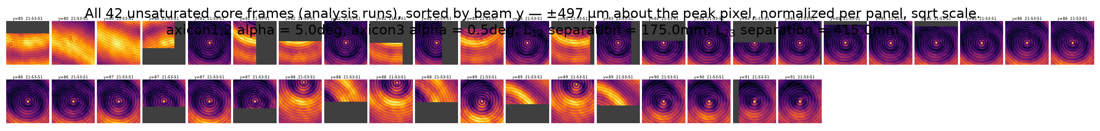

<Figure size 640x480 with 0 Axes>

In [47]:
# --- core-frame gallery ------------------------------------------------------
order = np.lexsort((ct_frames, ct_runs, ct_ys))
N_COLS_CF = 24
n_rows_cf = int(np.ceil(len(order) / N_COLS_CF))
cmap_cf = plt.get_cmap("inferno").copy()
cmap_cf.set_bad("0.25")
fig, axes = plt.subplots(n_rows_cf, N_COLS_CF,
                         figsize=(0.95 * N_COLS_CF, 1.08 * n_rows_cf),
                         squeeze=False)
for ax in np.ravel(axes):
    ax.set_axis_off()
for ax, i in zip(np.ravel(axes), order):
    t = core_thumbs[i]
    ax.imshow(np.sqrt(np.clip(t / np.nanmax(t), 0, 1)), cmap=cmap_cf,
              vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"y={ct_ys[i]:g}  {str(ct_runs[i])[-8:]}", fontsize=4.5, pad=1.5)
fig.subplots_adjust(top=0.90, hspace=0.25, wspace=0.05)
fig.suptitle(f"All {len(order)} unsaturated core frames (analysis runs), "
             "sorted by beam y — ±497 µm about the peak pixel, "
             "normalized per panel, sqrt scale.\n" + OPTIC_TITLE,
             y=0.999, fontsize=16)
save_fig("core_frame_gallery_v1")
plt.close(fig)
# inline preview only — the full-res png is large
plt.tight_layout()
import io
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
with PILImage.open(IMAGES_DIR / "core_frame_gallery_v1.png") as _im:
    _im.thumbnail((1100, 4400))
    _buf = io.BytesIO()
    _im.save(_buf, "png")
display(IPImage(data=_buf.getvalue()))

v2: 21 frames = 21 filled - 0 excluded + 0 backfilled
saved images/axicon3_central_bessel_lobe_2026_08_05/core_frame_gallery_v2.png


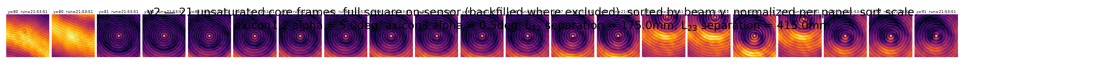

In [48]:
# --- v2 gallery: fills-the-square filter + arbitrary (y, run) exclusions -----
# The ±497 µm crop is NaN wherever it ran off the sensor, so "central lobe
# cut off" == any NaN in the thumbnail. On top of that, v2_filters_additional
# drops arbitrary (y, run) frames — applied to the frame list BEFORE the grid
# is laid out, so panels pack with no holes in the tiling. If an exclusion
# empties a y value entirely, BACKFILL_EMPTY_Y pulls the least-clipped
# remaining frame at that y back in (fill-the-square relaxed for that y only)
# so the y ladder stays complete. filled-and-kept selection for downstream
# fits: keep_v2 / order_v2.
v2_filters_additional = []
BACKFILL_EMPTY_Y = True

filled_mask = ~np.isnan(core_thumbs).any(axis=(1, 2))
excl_mask = np.zeros(len(ct_ys), bool)
for f in v2_filters_additional:
    excl_mask |= np.isclose(ct_ys, f["y"]) & (ct_runs == f["run"])
keep_v2 = filled_mask & ~excl_mask

if BACKFILL_EMPTY_Y:
    frac_on = 1 - np.isnan(core_thumbs).mean(axis=(1, 2))
    for y in np.unique(ct_ys):
        at_y = ct_ys == y
        if (keep_v2 & at_y).any():
            continue
        cand = np.where(at_y & ~excl_mask)[0]
        if len(cand) == 0:
            print(f"y={y:g}: every frame excluded — gap in the y ladder")
            continue
        pick = cand[np.argmax(frac_on[cand])]
        keep_v2[pick] = True
        print(f"y={y:g}: backfilled with edge-clipped {str(ct_frames[pick])} "
              f"({frac_on[pick]:.0%} on-sensor)")

order_v2 = order[keep_v2[order]]
print(f"v2: {int(keep_v2.sum())} frames = {int(filled_mask.sum())} filled "
      f"- {int((filled_mask & excl_mask).sum())} excluded "
      f"+ {int((keep_v2 & ~filled_mask).sum())} backfilled")

n_rows_v2 = int(np.ceil(len(order_v2) / N_COLS_CF))
fig, axes = plt.subplots(n_rows_v2, N_COLS_CF,
                         figsize=(0.95 * N_COLS_CF, 1.08 * n_rows_v2),
                         squeeze=False)
for ax in np.ravel(axes):
    ax.set_axis_off()
for ax, i in zip(np.ravel(axes), order_v2):
    t = core_thumbs[i]
    ax.imshow(np.sqrt(np.clip(t / np.nanmax(t), 0, 1)), cmap=cmap_cf,
              vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"y={ct_ys[i]:g}  run={str(ct_runs[i])[-8:]}", fontsize=4.5,
                 pad=1.5)
fig.subplots_adjust(top=0.99, hspace=0.25, wspace=0.05)
fig.suptitle(f"v2 — {len(order_v2)} unsaturated core frames, full square "
             "on-sensor (backfilled where excluded), sorted by beam y; "
             "normalized per panel, sqrt scale.\n" + OPTIC_TITLE,
             y=0.999, fontsize=13)
save_fig("core_frame_gallery_v2")
plt.close(fig)
import io
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
with PILImage.open(IMAGES_DIR / "core_frame_gallery_v2.png") as _im:
    _im.thumbnail((1100, 4400))
    _buf = io.BytesIO()
    _im.save(_buf, "png")
display(IPImage(data=_buf.getvalue()))

In [49]:
# --- 1D J0^2 fits per v2 frame: X lineout, Z lineout, radial profile ---------
# Preprocessing (input: the v2-selected thumbnails, 6.9 um/px):
#   1. per frame, core pixel = argmax of the thumbnail (crops are centered on
#      the raw-frame peak, so this is ~the panel center)
#   2. X lineout = the row through the core; Z lineout = the column; offsets
#      in um from the core pixel. Camera px maps: row -> machine Z, col -> X
#      (both flipped 180 deg vs machine axes — symmetric profiles, so the
#      flip does not affect the fits)
#   3. radial profile = azimuthal mean in 6.9 um bins about the sub-pixel
#      centroid of the 5x5 block at the core
#   4. each of the three fits A*J0^2(k*(u-u0)) + C by least squares
#      (scipy curve_fit) over |u| <= 450 um; u0 fixed at 0 for the radial fit
#   5. k bounds 0.2-4x ideal (jul30 used 0.5-1.5x, which PINS most fits in
#      this L23=415 geometry — the core is ~1.8x tighter than ideal near
#      y=60, cf. axicon3_fit_quality_2026_08_05)
#   6. no cache — recomputed from the thumbnails in ~30 s
import sys
from scipy.optimize import curve_fit
from scipy.special import j0

sys.path.insert(0, str(REPO.parent / "bessel-beam-webapp"))
from simulator.qdht_axicon import axicon_kr

KR_IDEAL = axicon_kr(ALPHA3_DEG)          # rad/m, ideal axicon-3 cone
UM_PER_PX = 6.9
FIT_HALF_UM = 450.0


def j0sq_c(u_um, A, k, u0_um, C):
    return A * j0(k * (u_um - u0_um) * 1e-6) ** 2 + C


def fit_profile(u_um, I, free_center=True):
    ok = np.isfinite(I) & (np.abs(u_um) <= FIT_HALF_UM)
    p0 = [np.nanmax(I[ok]), KR_IDEAL, 0.0, 0.0]
    lo = [0, 0.2 * KR_IDEAL, -35.0, -np.inf]
    hi = [np.inf, 4.0 * KR_IDEAL, 35.0, np.inf]
    if not free_center:
        lo[2], hi[2] = -1e-9, 1e-9
    popt, pcov, infodict, mesg, ier = curve_fit(j0sq_c, u_um[ok], I[ok], p0=p0, bounds=(lo, hi), full_output=True)
    # err = np.sqrt(np.diag(pcov[0,0]))
    perr = np.sqrt(np.diag(pcov))
    resid = I[ok] - j0sq_c(u_um[ok], *popt)
    return popt, float(np.sqrt(np.mean(resid ** 2)) / popt[0]), perr


fits1d = []
for i in order_v2:
    t = core_thumbs[i]
    py, px = np.unravel_index(np.nanargmax(t), t.shape)
    x_u = (np.arange(t.shape[1]) - px) * UM_PER_PX
    z_u = (np.arange(t.shape[0]) - py) * UM_PER_PX
    # sub-pixel centroid for the radial profile
    w = np.nan_to_num(t[max(py-2, 0):py+3, max(px-2, 0):px+3])
    wy, wx = np.mgrid[max(py-2, 0):py+3, max(px-2, 0):px+3]
    cy, cx = (w*wy).sum()/w.sum(), (w*wx).sum()/w.sum()
    yy, xx = np.mgrid[0:t.shape[0], 0:t.shape[1]]
    r_um = np.hypot(yy - cy, xx - cx) * UM_PER_PX
    fin = np.isfinite(t)
    b = (r_um[fin] / UM_PER_PX).astype(int)
    prof = (np.bincount(b, weights=t[fin]) /
            np.maximum(np.bincount(b), 1))
    r_cent = (np.arange(len(prof)) + 0.5) * UM_PER_PX
    px_fit, rms_x, perr_x = fit_profile(x_u, t[py, :])
    pz_fit, rms_z, perr_z = fit_profile(z_u, t[:, px])
    pr_fit, rms_r, perr_r = fit_profile(r_cent, prof, free_center=False)
    fits1d.append(dict(i=i, y=float(ct_ys[i]), run=str(ct_runs[i]),
                       x_u=x_u, z_u=z_u, Ix=t[py, :], Iz=t[:, px],
                       r=r_cent, Ir=prof,
                       px=px_fit, pz=pz_fit, pr=pr_fit,
                       rms=(rms_x, rms_z, rms_r),
                       err=(perr_x, perr_z, perr_r)))
kx = np.array([f["px"][1] for f in fits1d])
kz = np.array([f["pz"][1] for f in fits1d])
kr_ = np.array([f["pr"][1] for f in fits1d])
print(f"{len(fits1d)} frames fit | ideal kr3 = {KR_IDEAL:.4g} rad/m")
for nm, k in (("x", kx), ("z", kz), ("radial", kr_)):
    print(f"  k_{nm}: median {np.median(k):.4g} rad/m "
          f"({np.median(k)/KR_IDEAL - 1:+.1%} vs ideal), "
          f"IQR {np.percentile(k, 25)/KR_IDEAL - 1:+.1%} … "
          f"{np.percentile(k, 75)/KR_IDEAL - 1:+.1%}")

21 frames fit | ideal kr3 = 3.868e+04 rad/m
  k_x: median 5.904e+04 rad/m (+52.6% vs ideal), IQR +17.0% … +52.9%
  k_z: median 5.002e+04 rad/m (+29.3% vs ideal), IQR +6.2% … +52.3%
  k_radial: median 5.831e+04 rad/m (+50.7% vs ideal), IQR +21.0% … +51.6%


saved images/axicon3_central_bessel_lobe_2026_08_05/core_1d_profiles_gallery.png


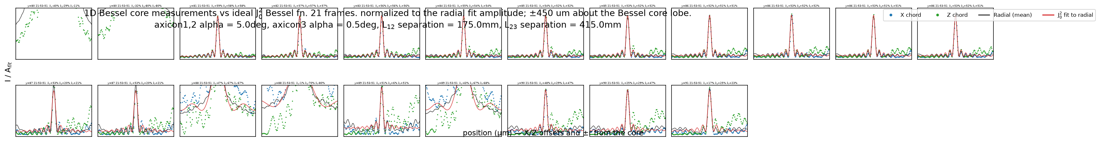

In [50]:
# --- per-frame 1D comparison gallery -----------------------------------------
N_COLS_1D = 12
n_rows_1d = int(np.ceil(len(fits1d) / N_COLS_1D))
u_fine = np.linspace(-FIT_HALF_UM, FIT_HALF_UM, 400)
fig, axes = plt.subplots(n_rows_1d, N_COLS_1D,
                         figsize=(1.9 * N_COLS_1D, 1.35 * n_rows_1d),
                         squeeze=False)
for ax in np.ravel(axes):
    ax.set_axis_off()
for ax, f in zip(np.ravel(axes), fits1d):
    ax.set_axis_on()
    ax.set_xticks([]); ax.set_yticks([])
    A = f["pr"][0]
    ax.plot(f["x_u"], f["Ix"] / A, ".", ms=1.2, color="tab:blue")

    ax.plot(f["z_u"], f["Iz"] / A, ".", ms=1.2, color="tab:green")
    ax.plot(f["r"], f["Ir"] / A, "-", color="0.2", lw=0.7)
    ax.plot(-f["r"], f["Ir"] / A, "-", color="0.2", lw=0.7)
    ax.plot(u_fine, j0sq_c(u_fine, *f["pr"]) / A, "-", color="tab:red",
            lw=0.8, alpha=0.85)
    ax.set_xlim(-FIT_HALF_UM, FIT_HALF_UM)
    ax.set_ylim(-0.05, 1.2)
    ax.set_title(f"y={f['y']:g} {f['run'][-8:]}  "
                 f"$k_x${f['px'][1]/KR_IDEAL-1:+.0%} "
                 f"$k_z${f['pz'][1]/KR_IDEAL-1:+.0%} "
                 f"$k_r${f['pr'][1]/KR_IDEAL-1:+.0%}", fontsize=4, pad=1.5)
h = [plt.Line2D([], [], marker=".", ls="", color="tab:blue", label="X chord"),
     plt.Line2D([], [], marker=".", ls="", color="tab:green", label="Z chord"),
     plt.Line2D([], [], color="0.2", label="Radial (mean)"),
     plt.Line2D([], [], color="tab:red", label="J$_0^2$ fit to radial")]
fig.legend(handles=h, loc="upper right", fontsize=8, ncol=4,
           bbox_to_anchor=(0.995, 0.999))
fig.supxlabel("position (µm) — X/Z offsets and ±r from the core",
              fontsize=11, y=0.0015)
fig.supylabel("I / A$_{fit}$", fontsize=11, x=0.002)
fig.subplots_adjust(top=0.99, bottom=0.006, left=0.012, hspace=0.5,
                    wspace=0.08)
fig.suptitle(f"1D Bessel core measurements vs ideal J$_0^2$ Bessel fn. {len(fits1d)} frames. "
             "normalized to the radial fit amplitude; ±450 um about the Bessel core lobe.\n" + OPTIC_TITLE,
             y=0.999, fontsize=13, x=0.35)
save_fig("core_1d_profiles_gallery")
plt.close(fig)
import io
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
with PILImage.open(IMAGES_DIR / "core_1d_profiles_gallery.png") as _im:
    _im.thumbnail((1100, 4400))
    _buf = io.BytesIO()
    _im.save(_buf, "png")
display(IPImage(data=_buf.getvalue()))

saved images/axicon3_central_bessel_lobe_2026_08_05/core_1d_fit_k_vs_y.png


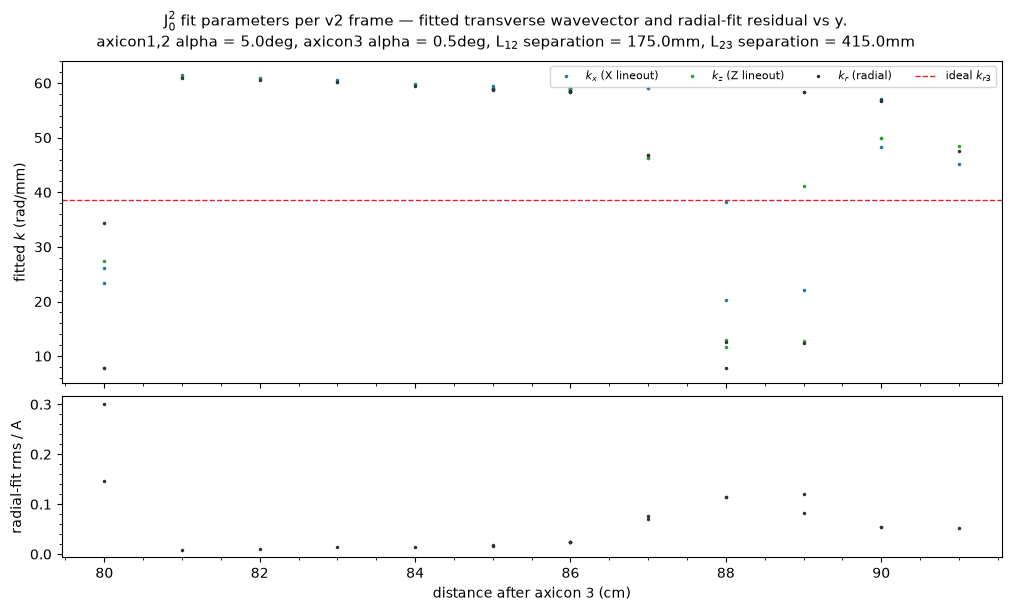

In [51]:
# --- fitted k vs y summary ---------------------------------------------------
ys_f = np.array([f["y"] for f in fits1d])
rms_r_f = np.array([f["rms"][2] for f in fits1d])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                               height_ratios=[2, 1], layout="constrained")
ax1.plot(ys_f, kx / 1e3, ".", ms=3, color="tab:blue", label="$k_x$ (X lineout)")
ax1.plot(ys_f, kz / 1e3, ".", ms=3, color="tab:green", label="$k_z$ (Z lineout)")
ax1.plot(ys_f, kr_ / 1e3, ".", ms=3, color="0.2", label="$k_r$ (radial)")
ax1.axhline(KR_IDEAL / 1e3, color="tab:red", ls="--", lw=1,
            label="ideal $k_{r3}$")
ax1.set_ylabel("fitted $k$ (rad/mm)")
ax1.legend(fontsize=8, ncol=4)
ax1.minorticks_on()
ax2.plot(ys_f, rms_r_f, ".", ms=3, color="0.2")
ax2.set_ylabel("radial-fit rms / A")
ax2.set_xlabel("distance after axicon 3 (cm)")
ax2.minorticks_on()
fig.suptitle("J$_0^2$ fit parameters per v2 frame — fitted transverse "
             "wavevector and radial-fit residual vs y.\n" + OPTIC_TITLE, fontsize=11)
save_fig("core_1d_fit_k_vs_y")
plt.show()

y=60: no v2 frame at this y — row skipped
y=70: no v2 frame at this y — row skipped
y=80: no fit with rms/A <= 0.06 — picking from all 2 candidates
y=100: no v2 frame at this y — row skipped
y=110: no v2 frame at this y — row skipped
y=120: no v2 frame at this y — row skipped
y=130: no v2 frame at this y — row skipped
saved images/axicon3_central_bessel_lobe_2026_08_05/core_frame_gallery_v3.png


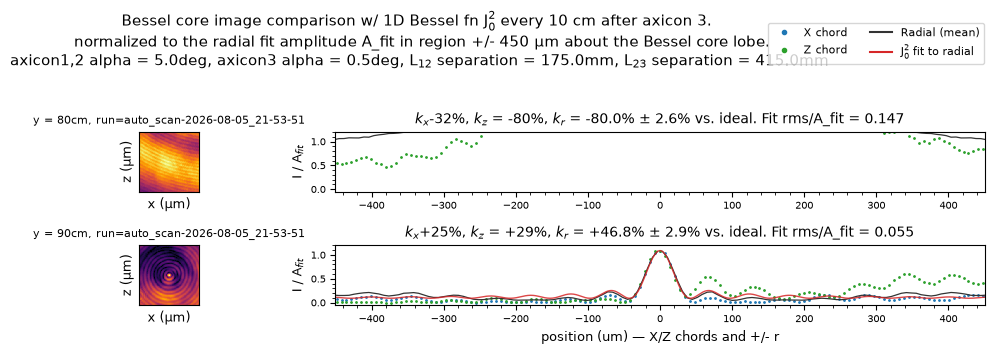

In [52]:
# --- v3 gallery: image + 1D comparison, one frame every 10 cm ----------------
# Selection: at each y in 60, 70, ..., 130 cm, the brightest v2 frame
# (largest radial-fit amplitude A) among clean fits — rms_r <= 0.06, the
# fit_ok cut from axicon3_fit_quality_2026_08_05; a halo-arc frame fit
# poorly can carry an inflated A, so rank only the clean ones and fall back
# to every candidate if a y has none. One row per y: thumbnail on the left,
# X/Z chords + radial profile + J0^2 fit on the right.
Y_TARGETS = np.arange(60, 131, 10)
RMS_OK = 0.06

picks = []
for y0 in Y_TARGETS:
    cands = [f for f in fits1d if np.isclose(f["y"], y0)]
    if not cands:
        print(f"y={y0}: no v2 frame at this y — row skipped")
        continue
    clean = [f for f in cands if f["rms"][2] <= RMS_OK]
    if not clean:
        print(f"y={y0}: no fit with rms/A <= {RMS_OK} — picking from all "
              f"{len(cands)} candidates")
    picks.append(max(clean or cands, key=lambda f: f["pr"][0]))

u_fine = np.linspace(-FIT_HALF_UM, FIT_HALF_UM, 500)
fig, axes = plt.subplots(len(picks), 2, figsize=(10, 1.75 * len(picks)),
                         squeeze=False, width_ratios=[1, 2.1], sharex=False, sharey=False)
for (ax_im, ax_pr), f in zip(axes, picks):
    t = core_thumbs[f["i"]]
    ax_im.imshow(np.sqrt(np.clip(t / np.nanmax(t), 0, 1)), cmap=cmap_cf,
                 vmin=0, vmax=1, interpolation="nearest",
                 extent=[-497, 497, -497, 497])
    ax_im.set_xticks([]); ax_im.set_yticks([])
    ax_im.set_xlabel(f"x (µm)", fontsize=9)
    ax_im.set_ylabel(f"z (µm)", fontsize=9)
    ax_im.set_title(f"y = {f['y']:g}cm, run={f['run']}", fontsize=8)

    A = f["pr"][0]
    ax_pr.set_ylabel("I / A$_{fit}$", fontsize=9)
    ax_pr.plot(f["x_u"], f["Ix"] / A, ".", ms=2, color="tab:blue")
    ax_pr.plot(f["z_u"], f["Iz"] / A, ".", ms=2, color="tab:green")
    ax_pr.plot(f["r"], f["Ir"] / A, "-", color="0.2", lw=0.9)
    ax_pr.plot(-f["r"], f["Ir"] / A, "-", color="0.2", lw=0.9)
    ax_pr.plot(u_fine, j0sq_c(u_fine, *f["pr"]) / A, "-", color="tab:red",
               lw=1.0, alpha=0.85)
    ax_pr.set_xlim(-FIT_HALF_UM, FIT_HALF_UM)
    ax_pr.set_ylim(-0.05, 1.2)
    ax_pr.tick_params(labelsize=7)
    ax_pr.minorticks_on()
    kdev = f["pr"][1] / KR_IDEAL - 1
    kerr = f["err"][2][1] / KR_IDEAL
    ax_pr.set_title(
                    f"$k_x${f['px'][1]/KR_IDEAL-1:+.0%}, "
                    f"$k_z$ = {f['pz'][1]/KR_IDEAL-1:+.0%}, "
                    f"$k_r$ = {kdev:+.1%} ± {kerr:.1%} vs. ideal. "
                    f"Fit rms/A_fit = {f['rms'][2]:.3f}", fontsize=10)

axes[-1][1].set_xlabel("position (um) — X/Z chords and +/- r", fontsize=9)
h = [plt.Line2D([], [], marker=".", ls="", color="tab:blue", label="X chord"),
     plt.Line2D([], [], marker=".", ls="", color="tab:green", label="Z chord"),
     plt.Line2D([], [], color="0.2", label="Radial (mean)"),
     plt.Line2D([], [], color="tab:red", label="J$_0^2$ fit to radial")]
fig.legend(handles=h, loc="upper right", fontsize=8, ncol=2,
           bbox_to_anchor=(0.99, 0.9765))
fig.suptitle(f"Bessel core image comparison w/ 1D Bessel fn J$_0^2$ every 10 cm after axicon 3. \n"
             " normalized to the radial fit amplitude A_fit in region +/- 450 µm about the Bessel core lobe." + "\n" + OPTIC_TITLE,
             fontsize=11, x=0.42, y=0.999)
plt.tight_layout(rect=[0, 0, 1, 0.966])
save_fig("core_frame_gallery_v3")
plt.show()

saved images/axicon3_central_bessel_lobe_2026_08_05/core_fit_kr_vs_y.png


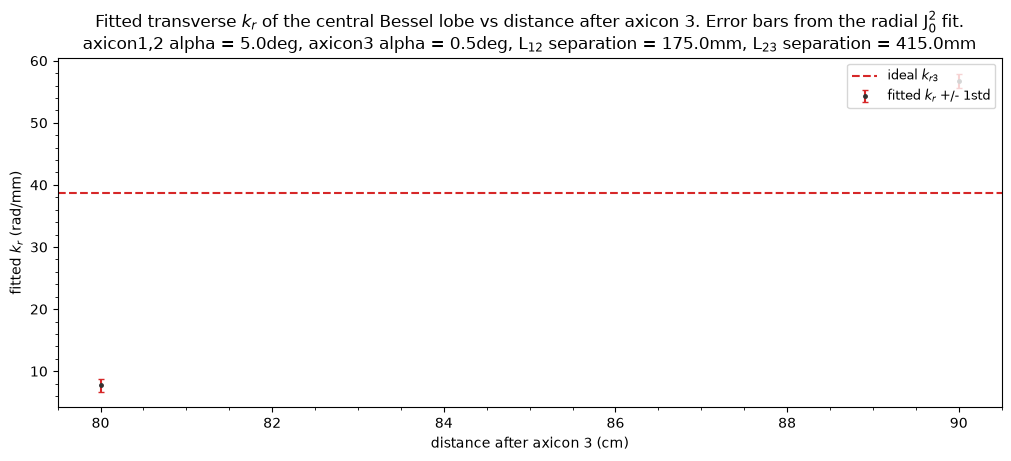

In [53]:
# Summary plot: central lobe fitted kr vs distance after axicon 3, with error bars
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.errorbar([f["y"] for f in picks], [f["pr"][1] / 1e3 for f in picks],
            yerr=[f["err"][2][1] / 1e3 for f in picks], fmt=".", ms=5,
            color="0.2", ecolor="tab:red", elinewidth=1.5, capsize=2, label="fitted $k_r$ +/- 1std")
ax.axhline(KR_IDEAL / 1e3, color="tab:red", ls="--", lw=1.5, label="ideal $k_{r3}$")
ax.set_xlabel("distance after axicon 3 (cm)")
ax.set_ylabel("fitted $k_r$ (rad/mm)")
ax.set_title("Fitted transverse $k_r$ of the central Bessel lobe vs distance after axicon 3. Error bars from the radial J$_0^2$ fit.\n" + OPTIC_TITLE)
ax.legend(fontsize=9, loc="upper right")
ax.minorticks_on()
save_fig("core_fit_kr_vs_y")

saved images/axicon3_central_bessel_lobe_2026_08_05/core_fit_kx_vs_y.png


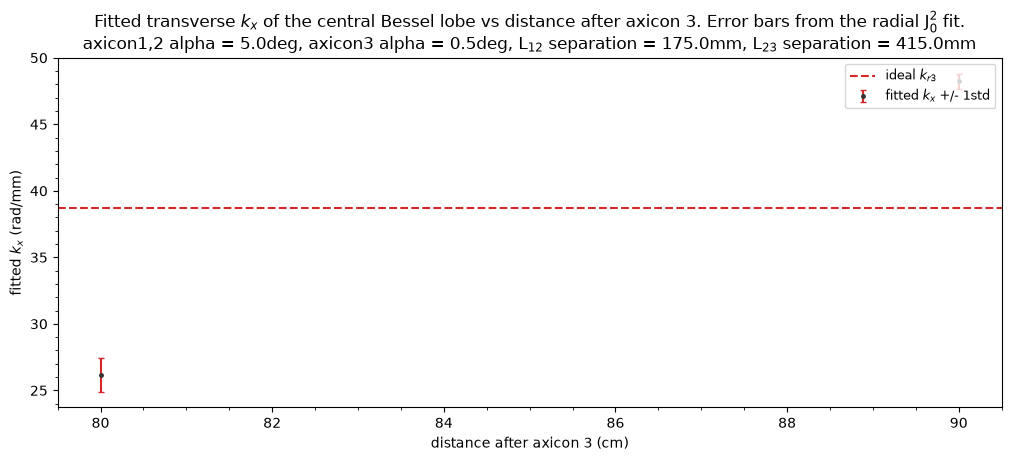

In [54]:
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.errorbar([f["y"] for f in picks], [f["px"][1] / 1e3 for f in picks],
            yerr=[f["err"][0][1] / 1e3 for f in picks], fmt=".", ms=5,
            color="0.2", ecolor="tab:red", elinewidth=1.5, capsize=2, label="fitted $k_x$ +/- 1std")
ax.axhline(KR_IDEAL / 1e3, color="tab:red", ls="--", lw=1.5, label="ideal $k_{r3}$")
ax.set_xlabel("distance after axicon 3 (cm)")
ax.set_ylabel("fitted $k_x$ (rad/mm)")
ax.set_title("Fitted transverse $k_x$ of the central Bessel lobe vs distance after axicon 3. Error bars from the radial J$_0^2$ fit.\n" + OPTIC_TITLE)
ax.legend(fontsize=9, loc="upper right")
ax.minorticks_on()
save_fig("core_fit_kx_vs_y")

In [55]:
# --- axial profile from the fits: central-lobe amplitude vs y ----------------
# "Plot the fits": instead of the raw peak-pixel rate, use the FITTED J0^2
# amplitude as the axial measurement.
#   1. A (counts) = fitted central-lobe peak of the azimuthal-mean radial
#      profile, per v2 frame — built from the whole lobe, not one pixel, so
#      it is robust to hot pixels, pixel-center sampling, and shot noise
#   2. divide by that frame's calibrated exposure (from the core-frame list)
#      -> counts/us, comparable across the exposure servo's staircase
#   3. 1-sigma error bars propagated from the fit covariance (perr)
#   4. gray dots: the SAME frames' raw peak-pixel rate, for comparison with
#      the old metric
#   5. orange: QDHT on-axis model (N=4096, within ~1% of N=16384), scaled
#      once so its window peak matches the fitted-amplitude peak over the
#      measured 60-132 cm span
from simulator.qdht_axicon import simulate_recorded_optic

exp_lookup = {(r["run"], r["frame"]): r["exposure_us"] for r in core_rows}
rate_lookup = {(r["run"], r["frame"]): r["rate_c_per_us"] for r in core_rows}

ys_a, A_rate, A_err, pk_rate = [], [], [], []
for f in fits1d:
    key = (f["run"], str(ct_frames[f["i"]]))
    T = exp_lookup.get(key)
    if T is None:
        print(f"MISSING manifest row for {key} — skipped")
        continue
    ys_a.append(f["y"])
    A_rate.append(f["pr"][0] / T)
    A_err.append(f["err"][2][0] / T)
    pk_rate.append(rate_lookup[key])
ys_a, A_rate = np.array(ys_a), np.array(A_rate)
A_err, pk_rate = np.array(A_err), np.array(pk_rate)

OPTIC = json.loads((RUN_DIRS[RUNS[0]] / "auto_scan_setup.json")
                   .read_text())["Metadata"]["OpticConfiguration"]
pair_a, model_a = simulate_recorded_optic(OPTIC, N=4096, Nz2=40, Nz3=400,
                                          verbose=False)
z_mod_cm = model_a["z3"] * 100.0
in_range = (z_mod_cm > 60) & (z_mod_cm < 135)
scale_a = A_rate.max() / model_a["onax"][in_range].max()
print(f"{len(ys_a)} frames; fit-amplitude peak {A_rate.max():.3f} counts/µs "
      f"at y = {ys_a[np.argmax(A_rate)]:g} cm; model scale {scale_a:.3g}")

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.plot(ys_a, pk_rate, ".", ms=2.5, color="0.7",
        label="Peak pixel rate (brightest pixel / exposure time)")
ax.errorbar(ys_a, A_rate, yerr=A_err, fmt=".", ms=4, color="0.15",
            elinewidth=0.8, label="Fitted radial J$_0^2$ amplitude / exposure time"
            "+/- 1std")
ax.plot(z_mod_cm, model_a["onax"] * scale_a, "-", color="tab:orange",
        lw=1.3, zorder=1, label="QDHT on-axis, scaled to fit peak")
ax.set_xlim(55, 140)
ax.set_xlabel("distance after axicon 3 (cm)")
ax.set_ylabel("central-lobe intensity (counts/µs, linear scale)")
ax.minorticks_on()
ax.legend(fontsize=9)
ax.set_title("Axial profile from the fits — central Bessel-lobe amplitude vs "
             "distance after axicon 3.\n" + OPTIC_TITLE, fontsize=10)
save_fig("axial_profile_from_fits")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/leigh/edu/Kolkowitz-Sr/Pi2Su26/bessel_beam_simulator/profiler/data/data/auto_scan-2026-08-05_21-43-49/auto_scan_setup.json'

saved images/axicon3_central_bessel_lobe_2026_08_05/axial_profile_from_fits_xz.png


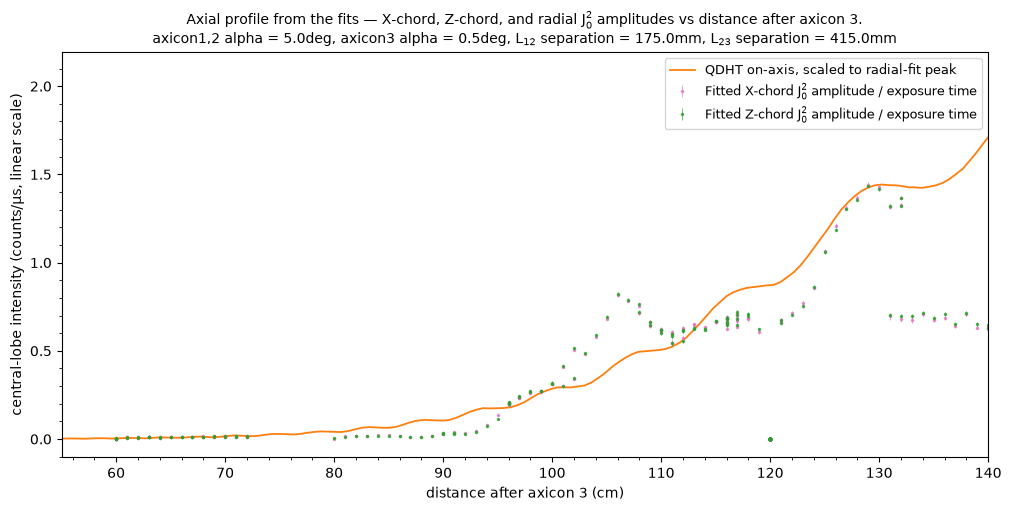

In [ ]:
# --- axial profile from the fits: X chord vs Z chord vs radial ---------------
# Same construction as above, for all three fit families: the fitted J0^2
# amplitude of the X chord, Z chord, and azimuthal-mean radial profile,
# each / that frame's exposure, 1-sigma error bars from the fit covariance
# (err = (perr_x, perr_z, perr_r); index 0 of each = sigma_A).
ys_c, Ax, Ax_e, Az, Az_e, Ar, Ar_e = [], [], [], [], [], [], []
for f in fits1d:
    key = (f["run"], str(ct_frames[f["i"]]))
    T = exp_lookup.get(key)
    if T is None:
        continue
    ys_c.append(f["y"])
    Ax.append(f["px"][0] / T); Ax_e.append(f["err"][0][0] / T)
    Az.append(f["pz"][0] / T); Az_e.append(f["err"][1][0] / T)
    Ar.append(f["pr"][0] / T); Ar_e.append(f["err"][2][0] / T)
ys_c = np.array(ys_c)

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.errorbar(ys_c, Ax, yerr=Ax_e, fmt=".", ms=3, color="tab:pink",
            elinewidth=0.6, alpha=0.75,
            label="Fitted X-chord J$_0^2$ amplitude / exposure time")
ax.errorbar(ys_c, Az, yerr=Az_e, fmt=".", ms=3, color="tab:green",
            elinewidth=0.6, alpha=0.75,
            label="Fitted Z-chord J$_0^2$ amplitude / exposure time")
# ax.errorbar(ys_c, Ar, yerr=Ar_e, fmt=".", ms=3.5, color="0.15",
#             elinewidth=0.6,
#             label="Fitted radial J$_0^2$ amplitude / exposure time")
ax.plot(z_mod_cm, model_a["onax"] * scale_a, "-", color="tab:orange",
        lw=1.3, zorder=1, label="QDHT on-axis, scaled to radial-fit peak")
ax.set_xlim(55, 140)
ax.set_xlabel("distance after axicon 3 (cm)")
ax.set_ylabel("central-lobe intensity (counts/µs, linear scale)")
ax.minorticks_on()
ax.legend(fontsize=9)
ax.set_title("Axial profile from the fits — X-chord, Z-chord, and radial "
             "J$_0^2$ amplitudes vs distance after axicon 3.\n" + OPTIC_TITLE,
             fontsize=10)
save_fig("axial_profile_from_fits_xz")
plt.show()

peak-anchored scale  0.01054
least-squares scale  0.00514  (-51.2% vs peak anchor)
saved images/axicon3_central_bessel_lobe_2026_08_05/axial_profile_from_fits_lsq.png


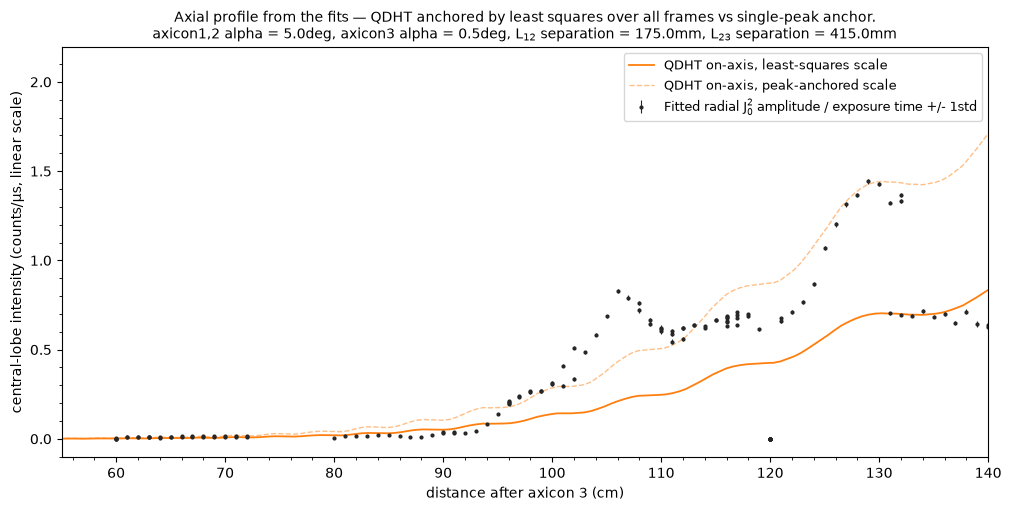

In [ ]:
# --- model anchoring by least squares (instead of the single-point peak) -----
# The QDHT curve's vertical scale is the ONE free parameter connecting model
# units (I/I_in) to camera units (counts/us). Anchoring at the single peak
# point makes the whole comparison hostage to one measurement; here the scale
# is fit by least squares over ALL v2 frames instead:
#     s_ls = argmin sum_i (A_i - s*m(y_i))^2  =  sum(A*m) / sum(m*m)
# so every point votes, weighted by model brightness.
m_at = np.interp(ys_a, z_mod_cm, model_a["onax"])
scale_ls = float(np.sum(A_rate * m_at) / np.sum(m_at * m_at))
print(f"peak-anchored scale  {scale_a:.4g}")
print(f"least-squares scale  {scale_ls:.4g}  "
      f"({scale_ls / scale_a - 1:+.1%} vs peak anchor)")

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.errorbar(ys_a, A_rate, yerr=A_err, fmt=".", ms=4, color="0.15",
            elinewidth=0.8,
            label="Fitted radial J$_0^2$ amplitude / exposure time +/- 1std")
ax.plot(z_mod_cm, model_a["onax"] * scale_ls, "-", color="tab:orange",
        lw=1.3, zorder=1, label="QDHT on-axis, least-squares scale")
ax.plot(z_mod_cm, model_a["onax"] * scale_a, "--", color="tab:orange",
        lw=1.0, alpha=0.5, zorder=1, label="QDHT on-axis, peak-anchored scale")
ax.set_xlim(55, 140)
ax.set_xlabel("distance after axicon 3 (cm)")
ax.set_ylabel("central-lobe intensity (counts/µs, linear scale)")
ax.minorticks_on()
ax.legend(fontsize=9)
ax.set_title("Axial profile from the fits — QDHT anchored by least squares "
             "over all frames vs single-peak anchor.\n" + OPTIC_TITLE,
             fontsize=10)
save_fig("axial_profile_from_fits_lsq")
plt.show()

saved images/axicon3_central_bessel_lobe_2026_08_05/axial_fit_model_ratio.png


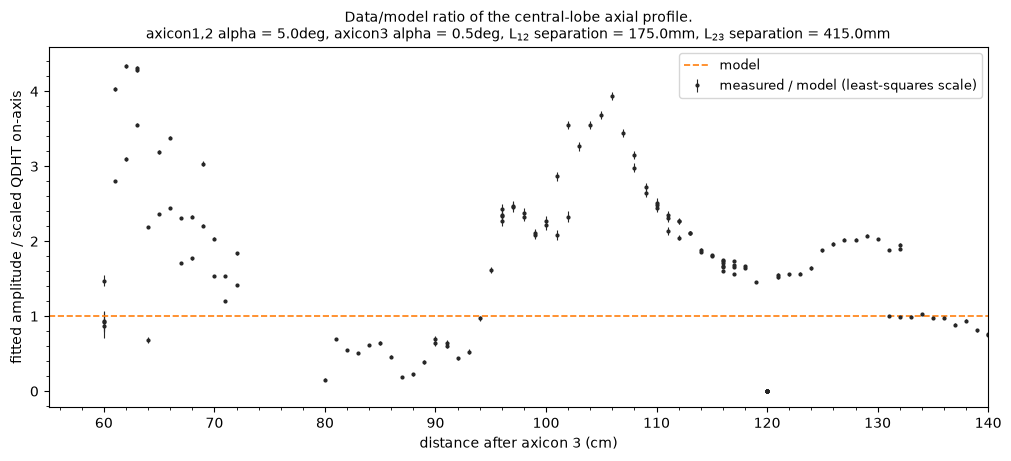

In [ ]:
# --- data / model ratio ------------------------------------------------------
# Removes the vertical scale from the argument entirely: plot
# A_rate / (s_ls * m(y)). A flat line at 1 = the model reproduces the axial
# SHAPE; structure in the ratio is model disagreement independent of any
# anchoring choice (s_ls only sets where 1.0 sits).
ratio = A_rate / (scale_ls * m_at)
ratio_err = A_err / (scale_ls * m_at)
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.errorbar(ys_a, ratio, yerr=ratio_err, fmt=".", ms=4, color="0.15",
            elinewidth=0.8, label="measured / model (least-squares scale)")
ax.axhline(1.0, color="tab:orange", ls="--", lw=1.2, label="model")
ax.set_xlim(55, 140)
ax.set_xlabel("distance after axicon 3 (cm)")
ax.set_ylabel("fitted amplitude / scaled QDHT on-axis")
ax.minorticks_on()
ax.legend(fontsize=9)
ax.set_title("Data/model ratio of the central-lobe axial profile.\n"
             + OPTIC_TITLE, fontsize=10)
save_fig("axial_fit_model_ratio")
plt.show()